# Lab 3: Implementation of Activation Functions
**Course:** Artificial Intelligence BS(AI) — SZABIST

**Name:** Anzal Azam Shaikh
**Roll No:** 24108106
**Section:** BSAUI-5A

### Objective
- Implement and compare Sigmoid, Tanh, ReLU (and Leaky ReLU) to understand their impact on model convergence and the importance of non-linearity.
- Build a simple feedforward neural network and see how the choice of activation function in the hidden layers changes the network's raw output.


## Import Libraries

- **Torch:** PyTorch main library.
- **torch.nn:** helps us build neural networks (layers, modules).
- **torch.nn.functional as F:** provides functions like activation functions (relu, softmax, leaky_relu).


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


## Plot the Activation Functions (Sigmoid, Tanh, ReLU, Leaky ReLU)

**Lab Task 1:** Add a fourth activation function, **Leaky ReLU** (`F.leaky_relu`), to the activation
function plot alongside Sigmoid, Tanh, and ReLU.


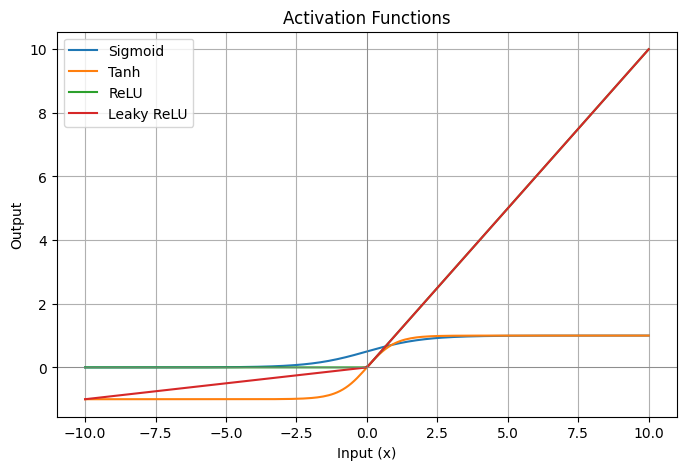

In [2]:
# Sample input values ranging from -10 to 10
x = torch.linspace(-10, 10, 200)

sigmoid_y = torch.sigmoid(x)
tanh_y = torch.tanh(x)
relu_y = F.relu(x)
leaky_relu_y = F.leaky_relu(x, negative_slope=0.1)  # Leaky ReLU added for Lab Task 1

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid_y, label='Sigmoid')
plt.plot(x, tanh_y, label='Tanh')
plt.plot(x, relu_y, label='ReLU')
plt.plot(x, leaky_relu_y, label='Leaky ReLU')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Activation Functions')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()


## Create a Custom Neural Network Class

Create a custom model class that is inherited from `nn.Module`. Each model has two hidden layers
and an output layer.


### Sigmoid Activation

In [3]:
class ModelSigmoid(nn.Module):
    #Input layer (4 features of the flower)
    #Hidden Layer 1 (number of neurons)
    #H2 (n)
    #Output (3 Classes of IRIS)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() #initiate our nn model
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))   # Hidden Layer 1
        x = torch.sigmoid(self.fc2(x))   # Hidden Layer 2
        x = self.out(x)                  # Output logits
        return x

torch.manual_seed(32)
model_sigmoid = ModelSigmoid()
print(model_sigmoid)


ModelSigmoid(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)


### Tanh Activation

In [4]:
class ModelTanh(nn.Module):
    #Input layer (4 features of the flower)
    #Hidden Layer 1 (number of neurons)
    #H2 (n)
    #Output (3 Classes of IRIS)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() #initiate our nn model
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))   # Hidden Layer 1
        x = torch.tanh(self.fc2(x))   # Hidden Layer 2
        x = self.out(x)
        return x

torch.manual_seed(32)
model_tanh = ModelTanh()
print(model_tanh)


ModelTanh(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)


### ReLU Activation

In [5]:
class ModelReLU(nn.Module):
    #Input layer (4 features of the flower)
    #Hidden Layer 1 (number of neurons)
    #H2 (n)
    #Output (3 Classes of IRIS)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() #initiate our nn model
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

torch.manual_seed(32)
model_relu = ModelReLU()
print(model_relu)


ModelReLU(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)


### Leaky ReLU Activation *(Lab Task 2)*

**Lab Task 2:** Build a fourth model class, `ModelLeakyReLU`, using Leaky ReLU in its hidden layers,
and add it to the output comparison on the 5 sample flowers.


In [6]:
class ModelLeakyReLU(nn.Module):
    #Input layer (4 features of the flower)
    #Hidden Layer 1 (number of neurons)
    #H2 (n)
    #Output (3 Classes of IRIS)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() #initiate our nn model
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), negative_slope=0.1)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.1)
        x = self.out(x)
        return x

torch.manual_seed(32)
model_leaky_relu = ModelLeakyReLU()
print(model_leaky_relu)


ModelLeakyReLU(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)


## Define the Dataset (IRIS Data)

Load the Iris dataset using sklearn and create a pandas DataFrame.


In [7]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Convert Features to FloatTensor and Labels to LongTensor for Training and Testing

PyTorch requires data to be in a specific format called a tensor to perform computations.

- **Features:** numerical data (sepal length, petal width, etc.) is converted to a `torch.FloatTensor`.
- **Labels:** the species (0, 1, 2) are converted to a `torch.LongTensor`, as required by
  PyTorch's `CrossEntropyLoss`.


In [8]:
# Convert features to a FloatTensor (PyTorch models expect tensors, not DataFrames)
X_tensor = torch.FloatTensor(X.values)
X_tensor[:5]


/tmp/ipykernel_592/2091808993.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  X_tensor = torch.FloatTensor(X.values)


tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000]])

## Running the Models

The models are **not trained** — instead, the same 5 sample flowers from the Iris dataset are
passed through all four models (Sigmoid, Tanh, ReLU, and Leaky ReLU) using their
randomly-initialized weights, and the raw outputs are compared.

This step demonstrates how the choice of activation function shapes the values flowing through the
network, even before any learning takes place. It is not meant to produce accurate predictions.


In [9]:
sample = X_tensor[:5]

with torch.no_grad():
    out_sigmoid = model_sigmoid(sample)
    out_tanh = model_tanh(sample)
    out_relu = model_relu(sample)
    out_leaky_relu = model_leaky_relu(sample)   # Lab Task 2: added to comparison

print('Sigmoid model output:\n', out_sigmoid)
print('\nTanh model output:\n', out_tanh)
print('\nReLU model output:\n', out_relu)
print('\nLeaky ReLU model output:\n', out_leaky_relu)


Sigmoid model output:
 tensor([[ 0.1862,  0.3240, -0.6258],
        [ 0.1876,  0.3243, -0.6256],
        [ 0.1882,  0.3253, -0.6260],
        [ 0.1881,  0.3255, -0.6270],
        [ 0.1864,  0.3245, -0.6263]])

Tanh model output:
 tensor([[-0.2537, -0.2381, -0.0376],
        [-0.2405, -0.2413, -0.0337],
        [-0.2406, -0.2332, -0.0346],
        [-0.2425, -0.2325, -0.0477],
        [-0.2543, -0.2339, -0.0413]])

ReLU model output:
 tensor([[ 0.1147,  0.0129, -0.1887],
        [ 0.1117,  0.0168, -0.2029],
        [ 0.1115,  0.0186, -0.1894],
        [ 0.1119,  0.0166, -0.1979],
        [ 0.1149,  0.0131, -0.1836]])

Leaky ReLU model output:
 tensor([[ 0.0729, -0.0638, -0.1189],
        [ 0.0722, -0.0572, -0.1336],
        [ 0.0729, -0.0526, -0.1238],
        [ 0.0750, -0.0543, -0.1334],
        [ 0.0737, -0.0626, -0.1157]])


## Analysis and Comparison

### Comparing the Activation Functions

- **Sigmoid** squashes any input into the range (0, 1). Its output is always positive, and it
  saturates (flattens) for large positive or negative inputs, which is why it can suffer from the
  vanishing gradient problem during training.
- **Tanh** squashes any input into the range (-1, 1) and is zero-centered, unlike Sigmoid. It also
  saturates for large inputs, but tends to produce more balanced gradients than Sigmoid.
- **ReLU** outputs 0 for any negative input and passes positive inputs through unchanged. It does
  not saturate on the positive side, is computationally cheap, and is the most widely used
  activation function in modern hidden layers. However, since its output (and gradient) is exactly
  0 for all negative inputs, neurons can get "stuck" and stop updating — a problem known as the
  **dying ReLU** problem.

### Lab Task 3: Leaky ReLU vs. ReLU

**How its shape differs from ReLU:**
Standard ReLU is `f(z) = max(0, z)`, so it is completely flat (output = 0, gradient = 0) for every
negative input. **Leaky ReLU** is defined as:

```
f(z) = z          if z > 0
f(z) = alpha * z  if z <= 0     (alpha is a small constant, e.g. 0.1)
```

Instead of clamping negative inputs to exactly zero, Leaky ReLU allows a small, non-zero,
negative slope (`alpha`) to pass through. Visually, on the plot above, ReLU is a flat line at 0 for
`x < 0`, while Leaky ReLU has a very shallow downward-sloping line for `x < 0` instead of being flat.

**What problem it is designed to solve:**
It is designed to fix the **dying ReLU problem**. With standard ReLU, if a neuron's weighted input
becomes negative during training, its gradient becomes exactly 0, so its weights stop updating and
the neuron effectively "dies" and never activates again. Because Leaky ReLU keeps a small non-zero
gradient (`alpha`) for negative inputs, a small gradient can still flow backward through the neuron
even when its input is negative. This keeps the neuron "alive" and able to recover during training,
while still keeping almost all of the benefits (cheap computation, no saturation for positive
inputs) that make ReLU-family activations popular.
